# Heart Disease Prediction - EDA and Preprocessing
**Student:** Umang Sharma  
**Roll No:** 2024AC05070  
**Course:** AIMLCZG523 - Machine Learning Operations (MLOps)

## Objective
Perform comprehensive Exploratory Data Analysis and data preprocessing for the Heart Disease UCI dataset.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)

## 1. Data Loading

In [2]:
# Load the dataset
import sys
sys.path.append('..')

from src.data.download_data import download_heart_disease_data

# Download data if not exists
data_path = Path('../data/raw/heart_disease.csv')
if not data_path.exists():
    df = download_heart_disease_data()
else:
    df = pd.read_csv(data_path)

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 2. Dataset Overview

In [3]:
# Basic information
print("\n=== Dataset Information ===")
print(df.info())

print("\n=== Statistical Summary ===")
print(df.describe())

print("\n=== Data Types ===")
print(df.dtypes)


=== Dataset Information ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB
None

=== Statistical Summary ===
          age     sex      cp  trestbps    chol     fbs  restecg  thalach  \
count  303.00  303.00  303.00    303.00  303.00  303.00   303.00   303.00   
me

In [4]:
# Feature descriptions
feature_descriptions = {
    'age': 'Age in years',
    'sex': 'Sex (1 = male; 0 = female)',
    'cp': 'Chest pain type (0-3)',
    'trestbps': 'Resting blood pressure (mm Hg)',
    'chol': 'Serum cholesterol (mg/dl)',
    'fbs': 'Fasting blood sugar > 120 mg/dl (1 = true; 0 = false)',
    'restecg': 'Resting electrocardiographic results (0-2)',
    'thalach': 'Maximum heart rate achieved',
    'exang': 'Exercise induced angina (1 = yes; 0 = no)',
    'oldpeak': 'ST depression induced by exercise',
    'slope': 'Slope of peak exercise ST segment (0-2)',
    'ca': 'Number of major vessels colored by fluoroscopy (0-3)',
    'thal': 'Thalassemia (1-3)',
    'target': 'Heart disease (0 = no, 1-4 = yes)'
}

print("\n=== Feature Descriptions ===")
for feat, desc in feature_descriptions.items():
    print(f"{feat:12s}: {desc}")


=== Feature Descriptions ===
age         : Age in years
sex         : Sex (1 = male; 0 = female)
cp          : Chest pain type (0-3)
trestbps    : Resting blood pressure (mm Hg)
chol        : Serum cholesterol (mg/dl)
fbs         : Fasting blood sugar > 120 mg/dl (1 = true; 0 = false)
restecg     : Resting electrocardiographic results (0-2)
thalach     : Maximum heart rate achieved
exang       : Exercise induced angina (1 = yes; 0 = no)
oldpeak     : ST depression induced by exercise
slope       : Slope of peak exercise ST segment (0-2)
ca          : Number of major vessels colored by fluoroscopy (0-3)
thal        : Thalassemia (1-3)
target      : Heart disease (0 = no, 1-4 = yes)


## 3. Missing Values Analysis


=== Missing Values ===
      Missing_Count  Percentage
ca                4        1.32
thal              2        0.66


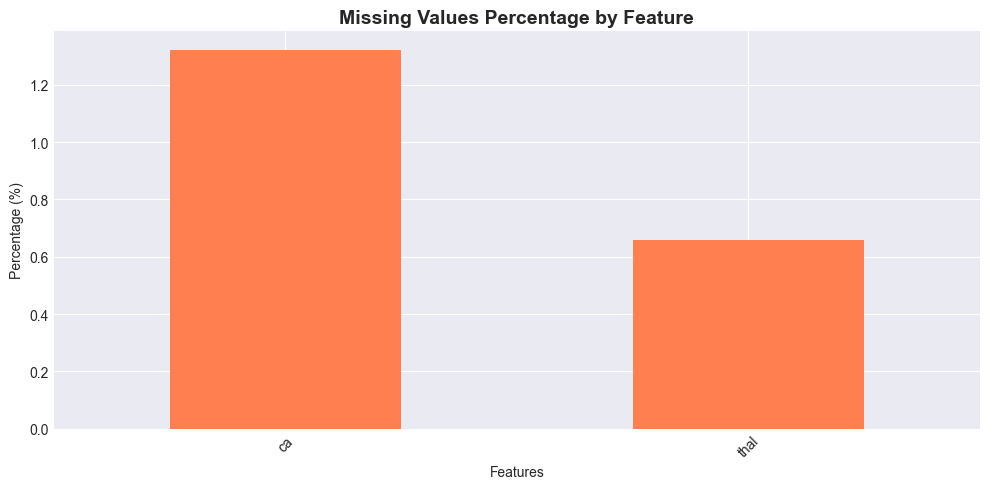

In [5]:
# Check for missing values
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing_Count': missing_values,
    'Percentage': missing_percent
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

print("\n=== Missing Values ===")
if len(missing_df) > 0:
    print(missing_df)
    
    # Visualize missing values
    plt.figure(figsize=(10, 5))
    missing_df['Percentage'].plot(kind='bar', color='coral')
    plt.title('Missing Values Percentage by Feature', fontsize=14, fontweight='bold')
    plt.xlabel('Features')
    plt.ylabel('Percentage (%)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('../screenshots/missing_values.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("✓ No missing values found!")

## 4. Target Variable Analysis

In [6]:
# Convert target to binary (0 = no disease, 1 = disease)
df['target_binary'] = (df['target'] > 0).astype(int)

print("\n=== Target Distribution ===")
print(df['target'].value_counts())
print("\n=== Binary Target Distribution ===")
print(df['target_binary'].value_counts())
print(f"\nClass Balance: {df['target_binary'].value_counts(normalize=True)}")


=== Target Distribution ===
target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

=== Binary Target Distribution ===
target_binary
0    164
1    139
Name: count, dtype: int64

Class Balance: target_binary
0    0.54
1    0.46
Name: proportion, dtype: float64


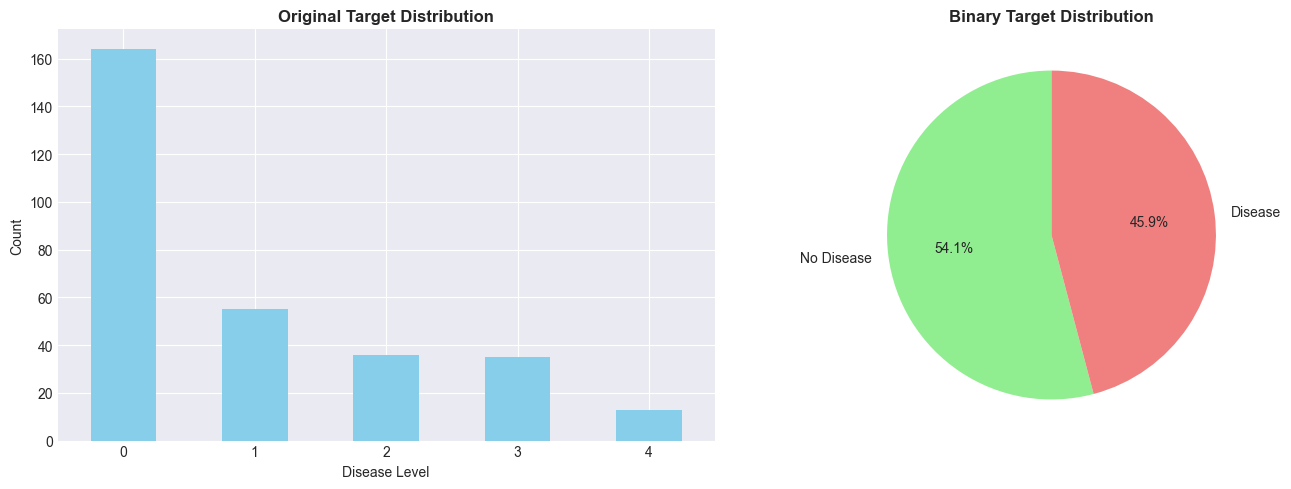

In [7]:
# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original target
df['target'].value_counts().plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Original Target Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Disease Level')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Binary target
target_counts = df['target_binary'].value_counts()
axes[1].pie(target_counts, labels=['No Disease', 'Disease'], autopct='%1.1f%%',
            colors=['lightgreen', 'lightcoral'], startangle=90)
axes[1].set_title('Binary Target Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../screenshots/target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Feature Distribution Analysis

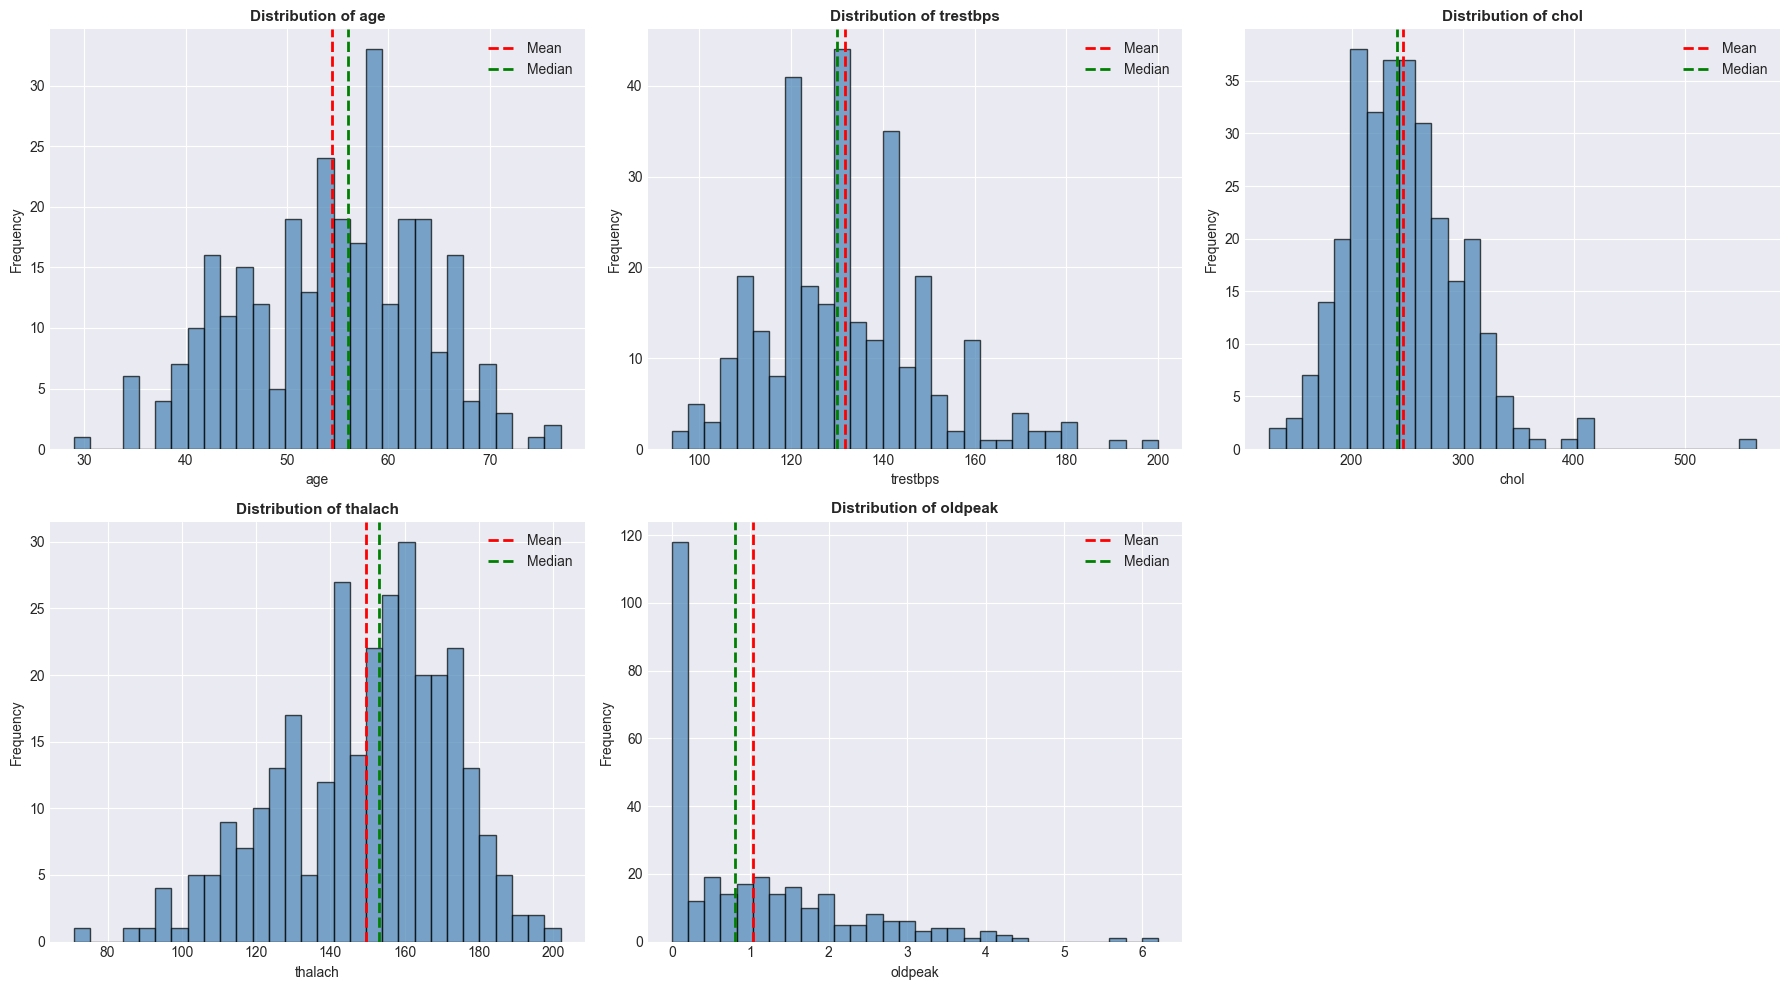

In [8]:
# Numerical features distribution
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_features):
    # Remove missing values for plotting
    data = df[col].dropna()
    
    axes[idx].hist(data, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].axvline(data.mean(), color='red', linestyle='--', linewidth=2, label='Mean')
    axes[idx].axvline(data.median(), color='green', linestyle='--', linewidth=2, label='Median')
    axes[idx].legend()

# Remove empty subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.savefig('../screenshots/feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Correlation Analysis

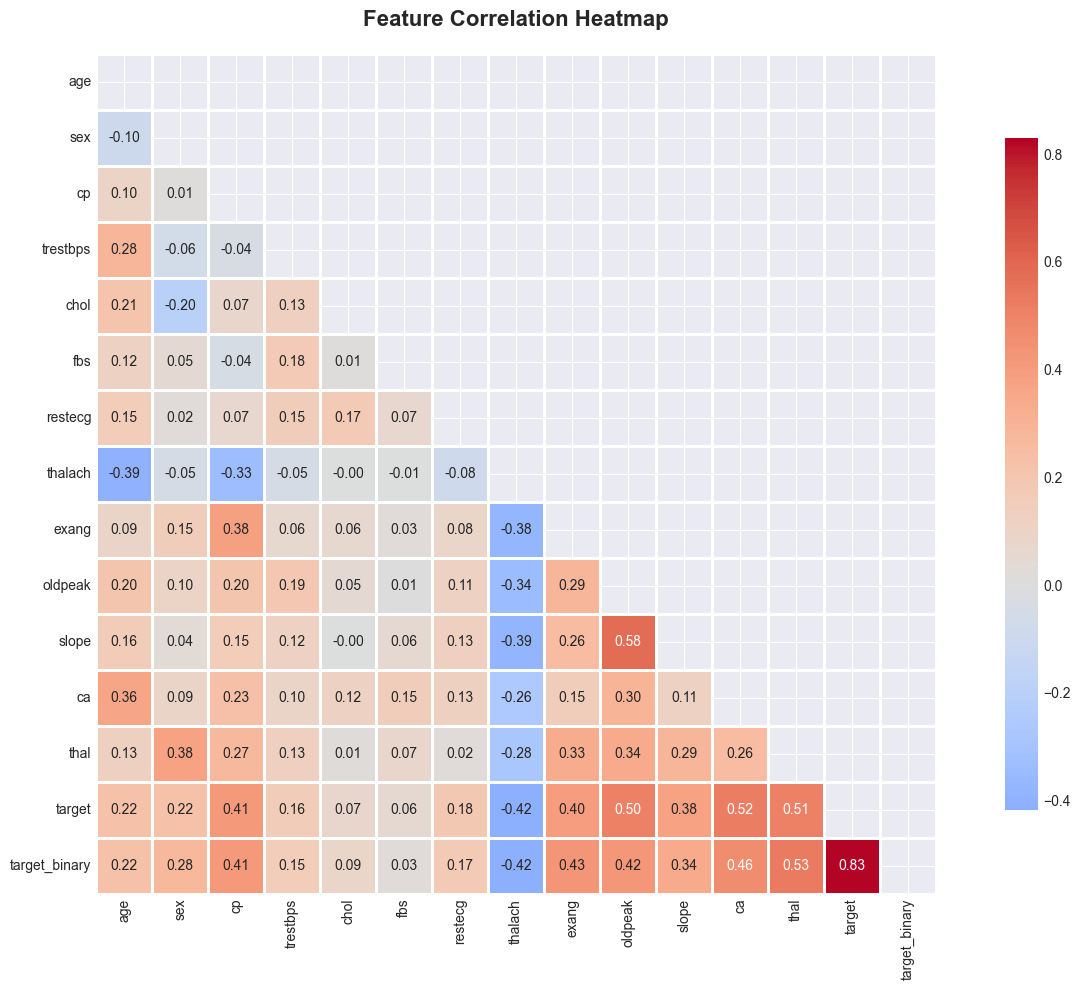


=== Top Correlations with Target (Binary) ===
target     0.83
thal       0.53
ca         0.46
exang      0.43
oldpeak    0.42
thalach    0.42
cp         0.41
slope      0.34
sex        0.28
age        0.22
Name: target_binary, dtype: float64


In [9]:
# Correlation matrix
plt.figure(figsize=(14, 10))

# Calculate correlation
correlation = df.corr()

# Create heatmap
mask = np.triu(np.ones_like(correlation, dtype=bool))
sns.heatmap(correlation, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": .8})

plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../screenshots/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Top correlations with target
print("\n=== Top Correlations with Target (Binary) ===")
target_corr = correlation['target_binary'].abs().sort_values(ascending=False)
print(target_corr[1:11])  # Exclude target itself

## 7. Categorical Features Analysis

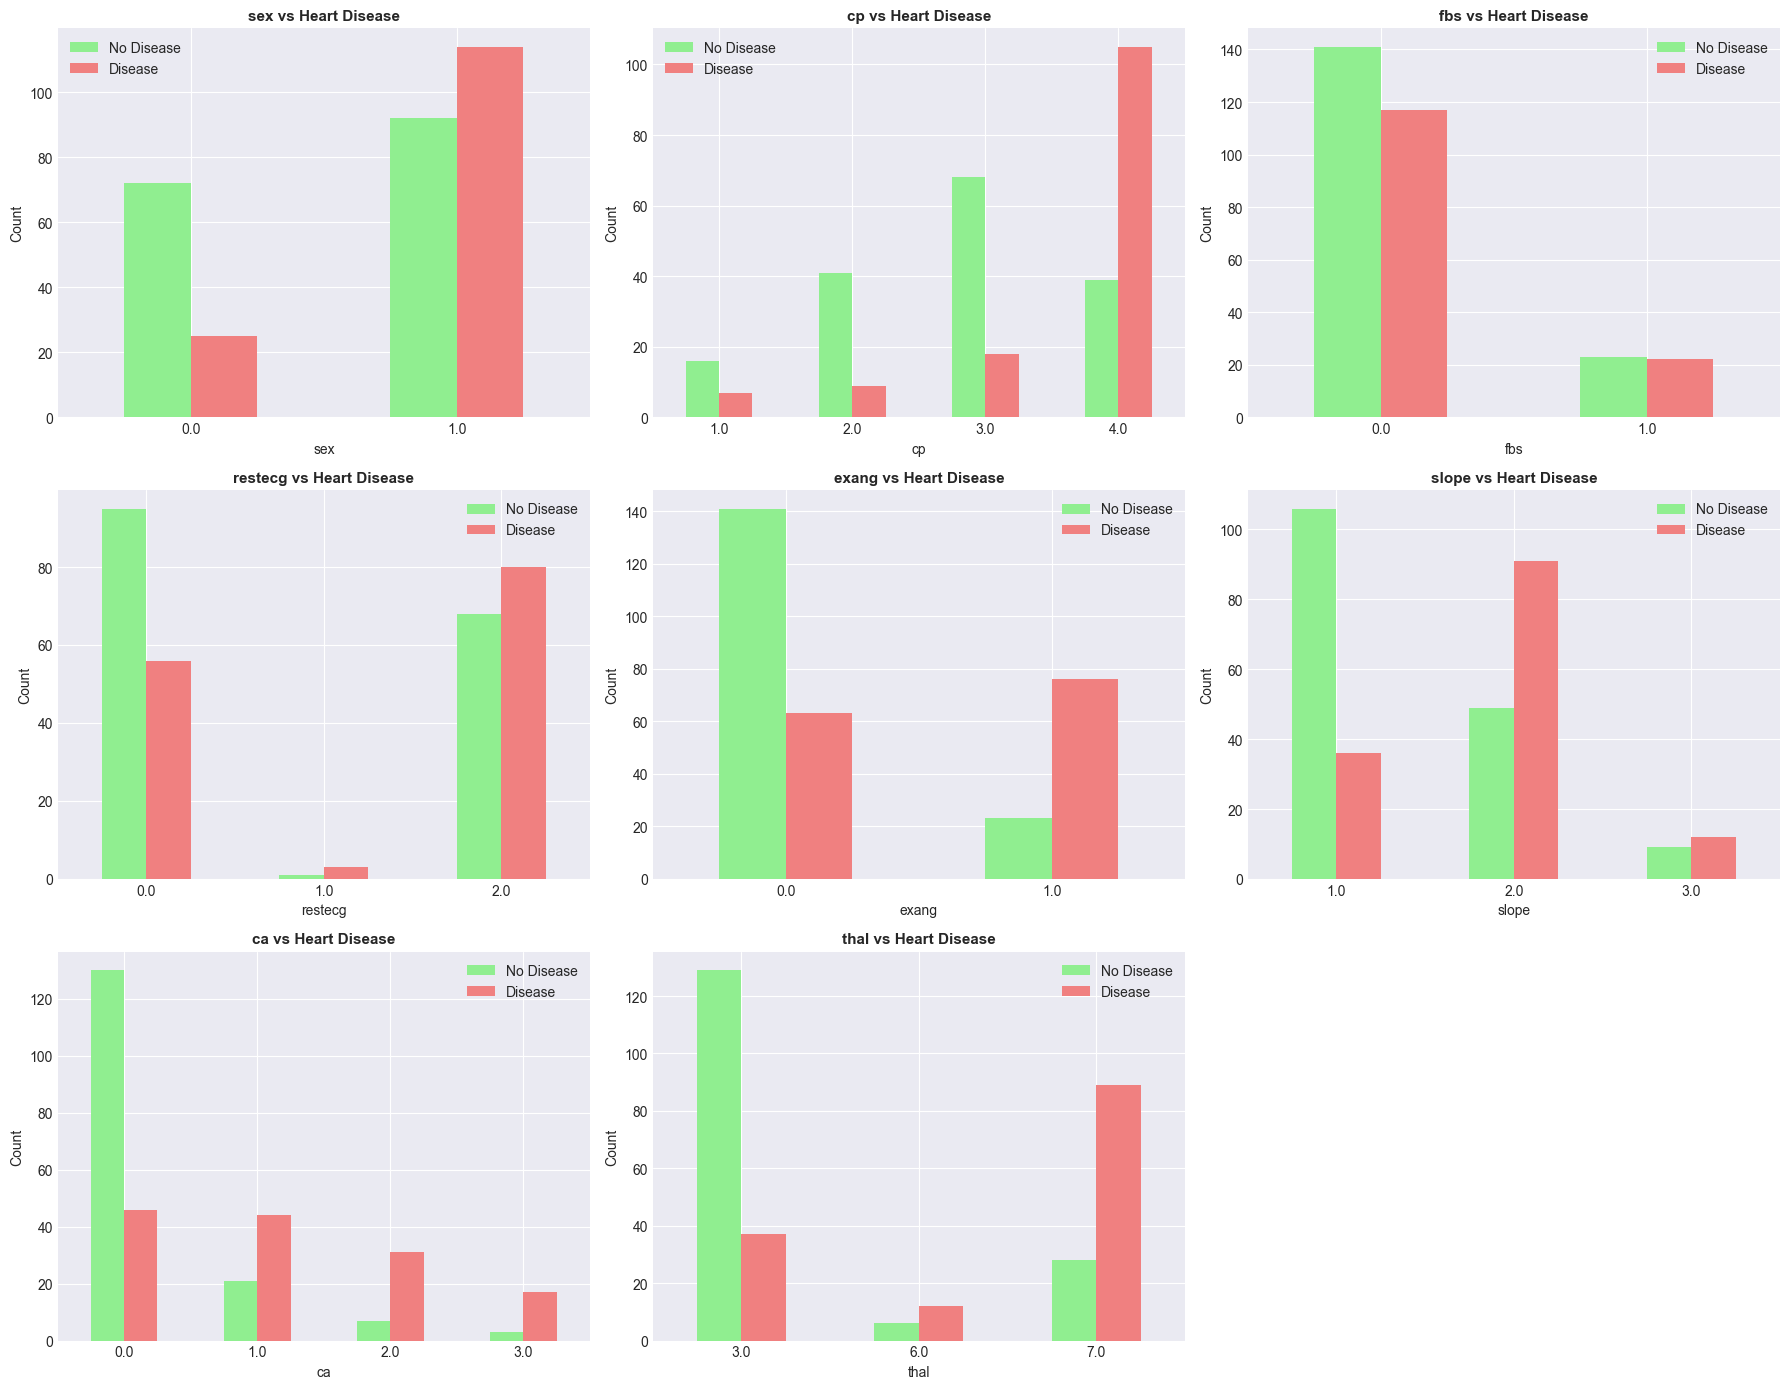

In [10]:
# Categorical features
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.ravel()

for idx, col in enumerate(categorical_features):
    # Count plot with target
    data = df[[col, 'target_binary']].dropna()
    pd.crosstab(data[col], data['target_binary']).plot(kind='bar', ax=axes[idx],
                                                         color=['lightgreen', 'lightcoral'])
    axes[idx].set_title(f'{col} vs Heart Disease', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Count')
    axes[idx].legend(['No Disease', 'Disease'])
    axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=0)

# Remove empty subplot
fig.delaxes(axes[8])

plt.tight_layout()
plt.savefig('../screenshots/categorical_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Age and Gender Analysis

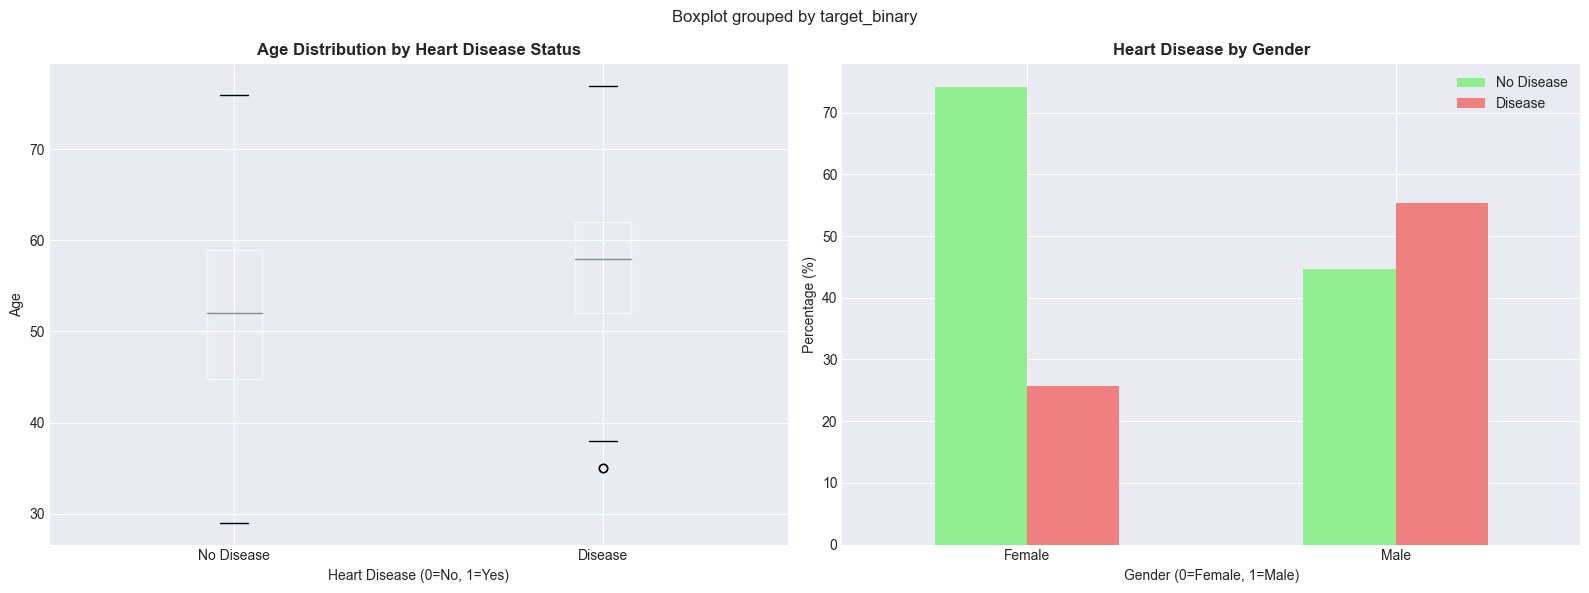

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Age distribution by disease
df.boxplot(column='age', by='target_binary', ax=axes[0])
axes[0].set_title('Age Distribution by Heart Disease Status', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Heart Disease (0=No, 1=Yes)')
axes[0].set_ylabel('Age')
plt.sca(axes[0])
plt.xticks([1, 2], ['No Disease', 'Disease'])

# Gender distribution by disease
gender_disease = pd.crosstab(df['sex'], df['target_binary'], normalize='index') * 100
gender_disease.plot(kind='bar', ax=axes[1], color=['lightgreen', 'lightcoral'])
axes[1].set_title('Heart Disease by Gender', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Gender (0=Female, 1=Male)')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(['No Disease', 'Disease'])
axes[1].set_xticklabels(['Female', 'Male'], rotation=0)

plt.tight_layout()
plt.savefig('../screenshots/age_gender_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Outlier Detection

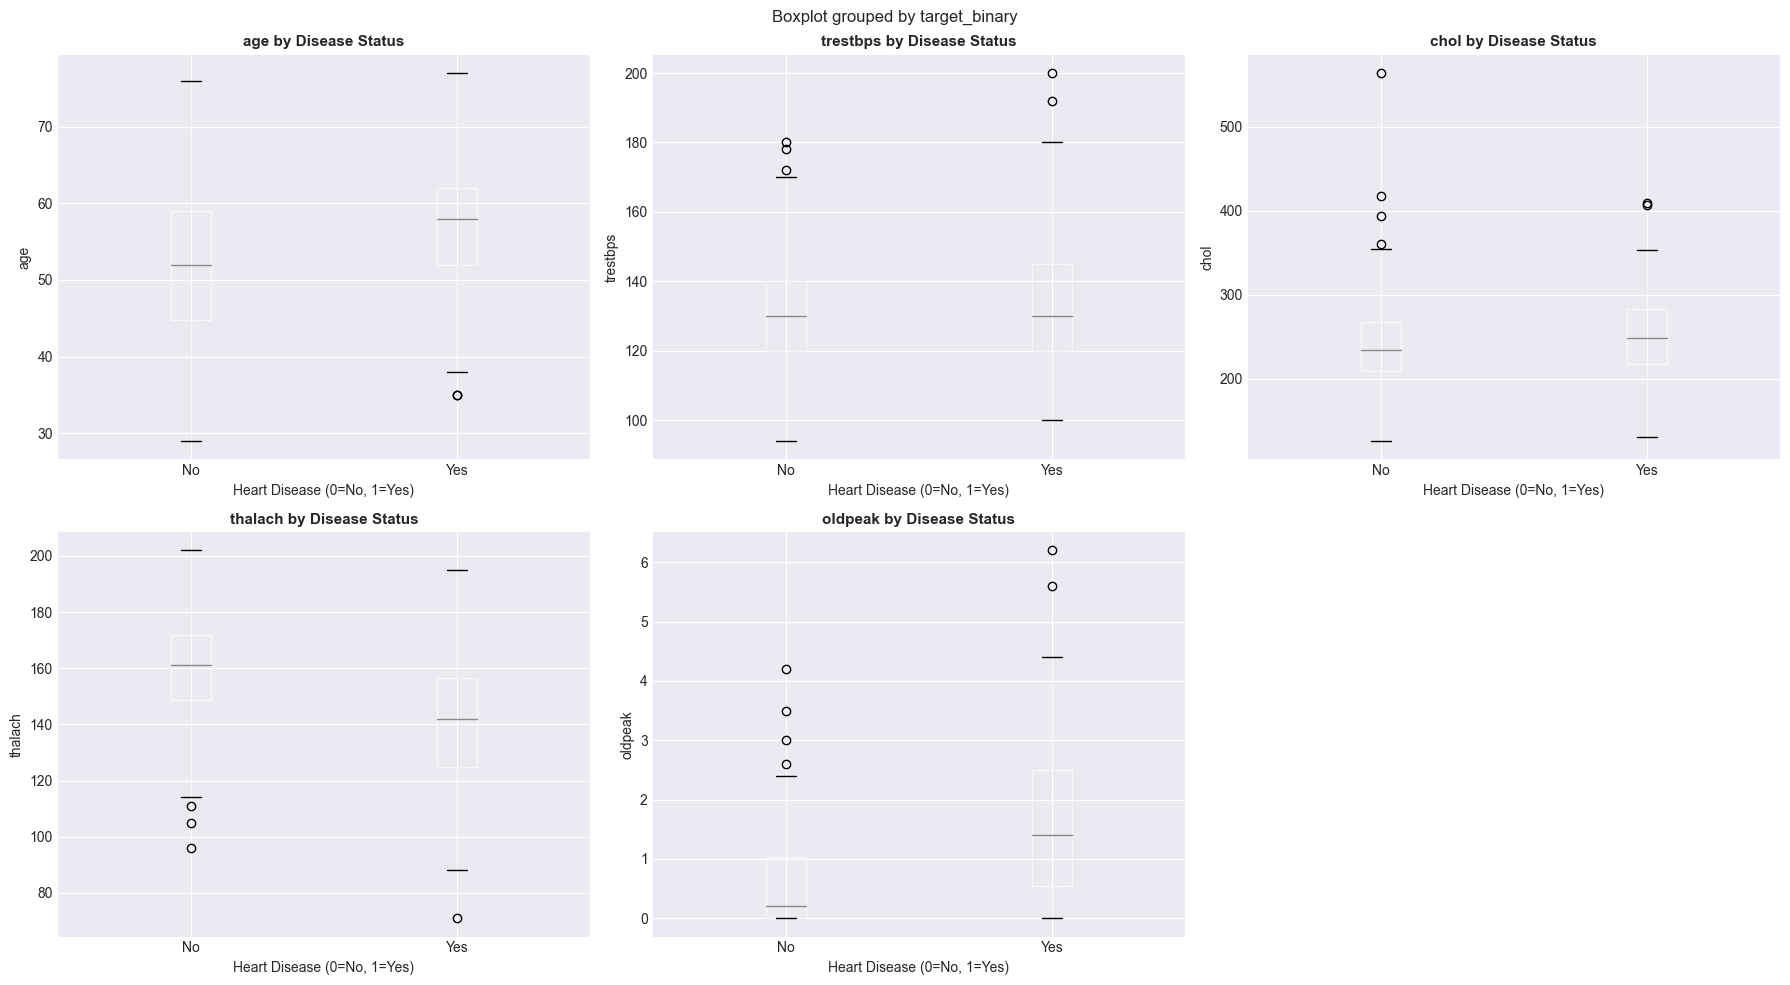

In [12]:
# Box plots for outlier detection
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_features):
    data = df[[col, 'target_binary']].dropna()
    data.boxplot(column=col, by='target_binary', ax=axes[idx])
    axes[idx].set_title(f'{col} by Disease Status', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Heart Disease (0=No, 1=Yes)')
    axes[idx].set_ylabel(col)
    plt.sca(axes[idx])
    plt.xticks([1, 2], ['No', 'Yes'])

# Remove empty subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.savefig('../screenshots/outlier_detection.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Data Preprocessing

In [13]:
# Handle missing values
print("\n=== Handling Missing Values ===")

# Check columns with missing values
cols_with_missing = df.columns[df.isnull().any()].tolist()
print(f"Columns with missing values: {cols_with_missing}")

# Strategy: Impute with median for numerical, mode for categorical
df_cleaned = df.copy()

for col in cols_with_missing:
    if col in numerical_features:
        df_cleaned[col].fillna(df_cleaned[col].median(), inplace=True)
        print(f"✓ {col}: Filled with median ({df_cleaned[col].median():.2f})")
    else:
        df_cleaned[col].fillna(df_cleaned[col].mode()[0], inplace=True)
        print(f"✓ {col}: Filled with mode ({df_cleaned[col].mode()[0]})")

print(f"\nMissing values after cleaning: {df_cleaned.isnull().sum().sum()}")


=== Handling Missing Values ===
Columns with missing values: ['ca', 'thal']
✓ ca: Filled with mode (0.0)
✓ thal: Filled with mode (3.0)

Missing values after cleaning: 0


In [14]:
# Save processed data
processed_path = Path('../data/processed')
processed_path.mkdir(parents=True, exist_ok=True)

output_file = processed_path / 'heart_disease_processed.csv'
df_cleaned.to_csv(output_file, index=False)

print(f"\n✓ Processed data saved to: {output_file}")
print(f"✓ Final shape: {df_cleaned.shape}")


✓ Processed data saved to: ../data/processed/heart_disease_processed.csv
✓ Final shape: (303, 15)


## 11. Key Insights

### Data Characteristics:
1. **Dataset Size**: The dataset contains patient health records with multiple features
2. **Target Variable**: Binary classification (presence/absence of heart disease)
3. **Missing Values**: Handled using median imputation for numerical and mode for categorical

### Feature Insights:
1. **Strong Predictors**: Features like chest pain type (cp), maximum heart rate (thalach), and exercise-induced angina (exang) show strong correlation with heart disease
2. **Age Factor**: Age distribution varies between diseased and healthy patients
3. **Gender Difference**: Gender shows different disease prevalence patterns

### Next Steps:
1. Feature engineering and scaling
2. Model development and training
3. Hyperparameter tuning
4. Model evaluation and selection

In [15]:
print("\n" + "="*60)
print("EDA and Preprocessing Complete!")
print("="*60)
print(f"\nProcessed Dataset: {df_cleaned.shape[0]} rows, {df_cleaned.shape[1]} columns")
print(f"Target Distribution: {df_cleaned['target_binary'].value_counts().to_dict()}")
print(f"All visualizations saved to: ../screenshots/")


EDA and Preprocessing Complete!

Processed Dataset: 303 rows, 15 columns
Target Distribution: {0: 164, 1: 139}
All visualizations saved to: ../screenshots/
